# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [2]:
# Load Dataset
df = pd.read_csv("creditcard.csv")

# Display first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# Exploratory Data Analysis

In [4]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1081


In [6]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (283726, 31)


# Data Preprocessing

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (226980, 30)
Testing Samples  : (56746, 30)


# Baseline Decision Tree Model

# Train the Model

In [9]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
# Predictions
dt_predictions = dt_model.predict(X_test)

# Prediction Probabilities
dt_probabilities = dt_model.predict_proba(X_test)[:, 1]

# Evaluate the Model

In [11]:
dt_accuracy = accuracy_score(y_test, dt_predictions)

dt_precision = precision_score(y_test, dt_predictions)

dt_recall = recall_score(y_test, dt_predictions)

dt_f1 = f1_score(y_test, dt_predictions)

dt_auc = roc_auc_score(y_test, dt_probabilities)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")
print(f"ROC AUC  : {dt_auc:.4f}")

Accuracy : 0.9990
Precision: 0.7204
Recall   : 0.7053
F1 Score : 0.7128
ROC AUC  : 0.8524


# Random Forest Classifier

# Train the Random Forest Model

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# Predict class labels
rf_predictions = rf_model.predict(X_test)

# Predict probabilities
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the Model

In [14]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_precision = precision_score(y_test, rf_predictions)

rf_recall = recall_score(y_test, rf_predictions)

rf_f1 = f1_score(y_test, rf_predictions)

rf_auc = roc_auc_score(y_test, rf_probabilities)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC AUC  : {rf_auc:.4f}")

Accuracy : 0.9995
Precision: 0.9718
Recall   : 0.7263
F1 Score : 0.8313
ROC AUC  : 0.9239


# Gradient Boosting Classifier

# Train the Gradient Boosting Model

In [16]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [17]:
# Predict class labels
gb_predictions = gb_model.predict(X_test)

# Predict probabilities
gb_probabilities = gb_model.predict_proba(X_test)[:, 1]

# Evaluate the Model

In [18]:
gb_accuracy = accuracy_score(y_test, gb_predictions)

gb_precision = precision_score(y_test, gb_predictions)

gb_recall = recall_score(y_test, gb_predictions)

gb_f1 = f1_score(y_test, gb_predictions)

gb_auc = roc_auc_score(y_test, gb_probabilities)

print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")
print(f"ROC AUC  : {gb_auc:.4f}")

Accuracy : 0.9992
Precision: 0.8611
Recall   : 0.6526
F1 Score : 0.7425
ROC AUC  : 0.8539


# COMPARISON

In [20]:
comparison_df = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall,
        gb_recall
    ],
    "F1-Score": [
        dt_f1,
        rf_f1,
        gb_f1
    ],
    "ROC-AUC": [
        dt_auc,
        rf_auc,
        gb_auc
    ]
})
comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.9990,0.7204,0.7053,0.7128,0.8524
1,Random Forest,0.9995,0.9718,0.7263,0.8313,0.9239
2,Gradient Boosting,0.9992,0.8611,0.6526,0.7425,0.8539


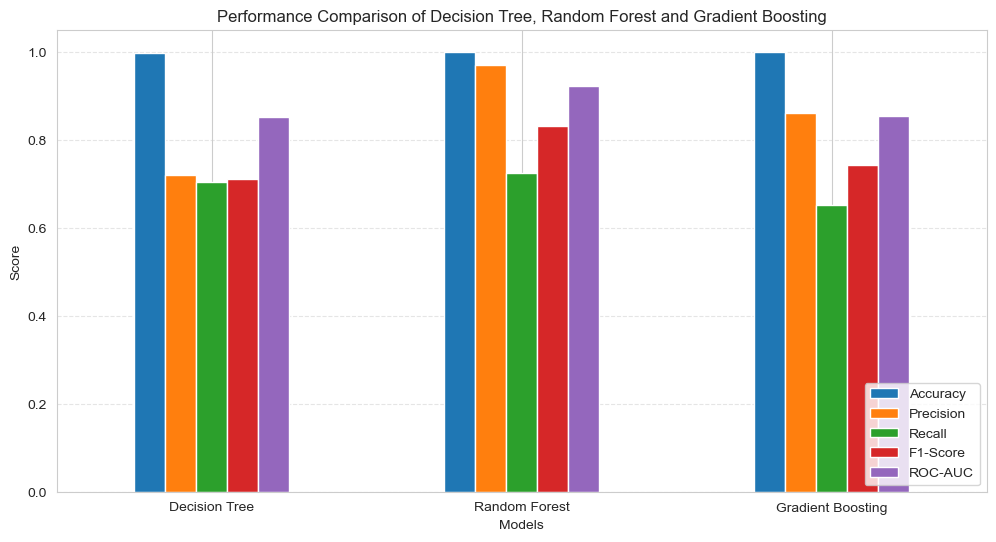

In [21]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

comparison_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Performance Comparison of Decision Tree, Random Forest and Gradient Boosting")

plt.ylabel("Score")

plt.xlabel("Models")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(loc="lower right")

plt.show()